In [1]:
from GWForge.population.mass import Mass
import numpy as np
import configparser

In [2]:
hyperpar_ini_file = 'pdb_hyperpar_defaults.ini'

In [3]:
cfg = configparser.ConfigParser()
# preserve key case from INI (case-sensitive keys)
cfg.optionxform = str
cfg.read(hyperpar_ini_file)
sec = cfg['hyperparameters']

# Load entire INI section as float-valued hyperparameters dictionary
hyperparams = {k: float(v) for k, v in sec.items()}
print("Loaded hyperparameters from INI file:", hyperparams)
hyperparams['mmin'] = 0.5
hyperparams['mmax'] = 350.0

Loaded hyperparameters from INI file: {'alpha_1': -4.509282643557759, 'alpha_dip': -1.6797692040029513, 'alpha_2': -0.9020346791414204, 'NSmin': 1.1763665089045245, 'NSmax': 4.094744137742966, 'BHmin': 7.7639549426962375, 'BHmax': 152.05597923492775, 'UPPERmin': 38.277415427531, 'UPPERmax': 66.57670527299628, 'n0': 50.0, 'n1': 50.0, 'n2': 50.0, 'n3': 30.0, 'n4': 30.0, 'n5': 10.041072204811995, 'mix1': 735.473275543081, 'mu1': 37.811196396328114, 'sig1': 17.12643064109277, 'mix2': 211.73332682799375, 'mu2': 8.897742041719734, 'sig2': 1.044692632025516, 'A': 0.091462424745936, 'A2': 0.8281652204882891, 'beta_pair_1': 0.9641379639323953, 'beta_pair_2': 2.160035650137072, 'mbreak': 5.0}


In [4]:
hyperparams.keys()

dict_keys(['alpha_1', 'alpha_dip', 'alpha_2', 'NSmin', 'NSmax', 'BHmin', 'BHmax', 'UPPERmin', 'UPPERmax', 'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'mix1', 'mu1', 'sig1', 'mix2', 'mu2', 'sig2', 'A', 'A2', 'beta_pair_1', 'beta_pair_2', 'mbreak', 'mmin', 'mmax'])

## Sample with rejection sampling

In [12]:
mass_model = Mass(mass_model='FullPop_GWTC4', 
                  number_of_samples=50000, 
                  parameters=hyperparams, 
                  full_pop_sampler='rejection')

In [13]:
mass_samples_rej = mass_model.sample(max_iterations=100000)

2026-02-20 17:25:39 Generating samples using fullpopgwtc4 model


Estimated maximum probability: 0.003387992175079073
Starting rejection sampling for 50000 samples...


Sampling: 100%|██████████| 50000/50000 [00:03<00:00, 16642.68samples/s]
2026-02-20 17:25:42 Rejection sampling acceptance rate: 0.0124


Sampling complete!
Generated 50000 samples (requested 50000)
Total proposals: 4042764
Acceptance rate: 0.0124


In [14]:
mass_samples_rej

{'mass_1_source': array([ 7.43899697, 10.08184293,  2.34269575, ...,  3.54048916,
         8.58578713,  1.55571284]),
 'mass_2_source': array([4.03600399, 1.98865166, 2.1636888 , ..., 3.25203618, 7.5738066 ,
        1.2281636 ]),
 'chirp_mass_source': array([4.72638435, 3.67209724, 1.95966015, ..., 2.95341808, 7.01730752,
        1.20165944]),
 'total_mass_source': array([11.47500097, 12.07049458,  4.50638455, ...,  6.79252534,
        16.15959372,  2.78387644]),
 'symmetric_mass_ratio': array([0.22801347, 0.13760953, 0.24960552, ..., 0.24954915, 0.24901955,
        0.24653907]),
 'mass_ratio': array([0.5425468 , 0.19725081, 0.92358933, ..., 0.91852737, 0.88213305,
        0.78945392])}

## Sample with importance sampling on m1, m2 proposals

In [15]:
mass_model = Mass(mass_model='FullPop_GWTC4', 
                  number_of_samples=50000, 
                  parameters=hyperparams, 
                  full_pop_sampler='importance_m1_m2')

In [16]:
mass_samples_imp_m1_m2 = mass_model.sample(oversample_factor=10)

2026-02-20 17:25:45 Generating samples using fullpopgwtc4 model


Drawing 500000 proposal samples...
Importance sampling complete.
Effective sample size ≈ 158534.9 / 249546


## Sample with importance sampling on m1, q proposals

In [17]:
mass_model = Mass(mass_model='FullPop_GWTC4', 
                  number_of_samples=50000, 
                  parameters=hyperparams, 
                  full_pop_sampler='importance_m1_q')

In [18]:
mass_samples_imp_m1_q = mass_model.sample(oversample_factor=5)

2026-02-20 17:26:22 Generating samples using fullpopgwtc4 model
100%|██████████| 250000/250000 [00:00<00:00, 817387.06it/s]

Effective sample size ≈ 14666.0 / 250000


## Sample with lint sampler

In [19]:
mass_model = Mass(mass_model='FullPop_GWTC4', 
                  number_of_samples=50000, 
                  parameters=hyperparams, 
                  full_pop_sampler='lint')

In [20]:
mass_samples_lint = mass_model.sample(grid_size=512)

2026-02-20 17:27:26 Generating samples using fullpopgwtc4 model


Building LintSampler grid: 512 x 512


## Compare with Fig. 2 of GWTC-4 population paper

In [21]:
import popsummary
pdb_file = '../../../data/GWTC-4_pop/analyses_AllCBC/AllCBC_FullPop.h5'
pdb_result = popsummary.popresult.PopulationResult(fname=pdb_file)

opening existing popsummary file: ../../../data/GWTC-4_pop/analyses_AllCBC/AllCBC_FullPop.h5


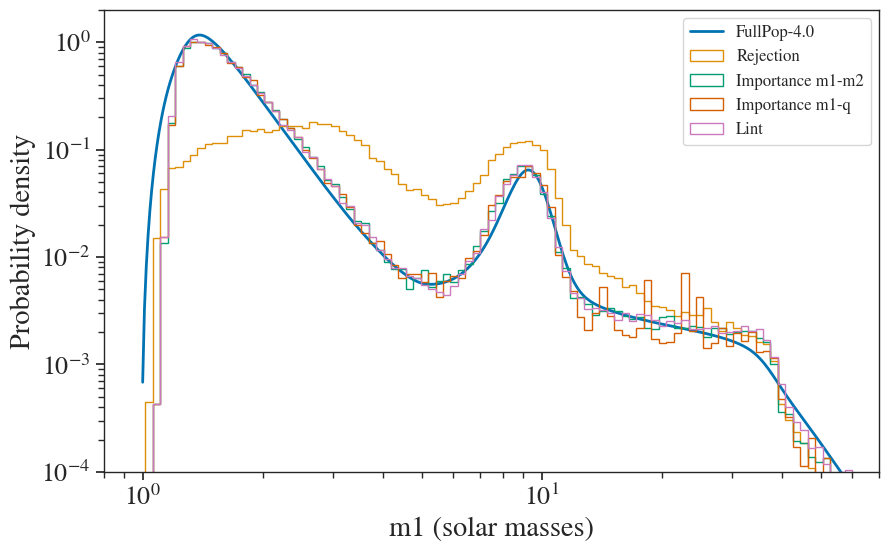

In [24]:
import seaborn as sns
import pylab as plt

plt.figure(figsize=(10,6))

pdb_m, pdb_Rm = pdb_result.get_rates_on_grids('primary_mass')
mean_curve = np.mean(pdb_Rm, axis=0)

bins = np.geomspace(0.1, 60, 150)

# Normalize
yy = mean_curve / np.trapz(mean_curve, pdb_m[0])

plt.plot(pdb_m[0], yy, label='FullPop-4.0', lw=2)

plt.hist(mass_samples_rej['mass_1_source'], bins=bins, density=True,
         histtype='step', label='Rejection')

plt.hist(mass_samples_imp_m1_m2['mass_1_source'], bins=bins, density=True,
         histtype='step', label='Importance m1-m2')

plt.hist(mass_samples_imp_m1_q['mass_1_source'], bins=bins, density=True,
         histtype='step', label='Importance m1-q')

plt.hist(mass_samples_lint['mass_1_source'], bins=bins, density=True,
         histtype='step', label='Lint')

plt.xlabel('m1 (solar masses)')
plt.ylabel('Probability density')
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.8, 70)
plt.ylim(1e-4, 2)
plt.legend(fontsize=12)

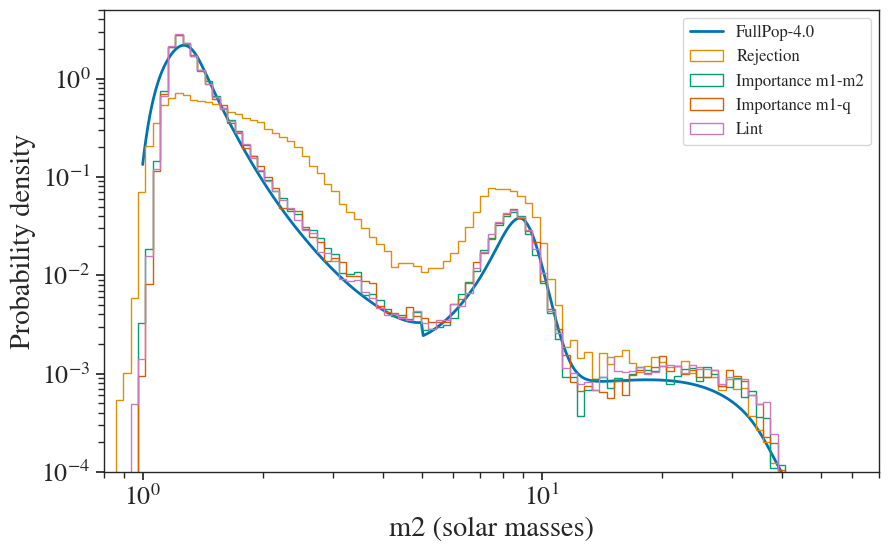

In [26]:
import seaborn as sns
import pylab as plt

plt.figure(figsize=(10,6))

pdb_m, pdb_Rm = pdb_result.get_rates_on_grids('secondary_mass')
mean_curve = np.mean(pdb_Rm, axis=0)

bins = np.geomspace(0.1, 60, 150)

# Normalize
yy = mean_curve / np.trapz(mean_curve, pdb_m[0])

plt.plot(pdb_m[0], yy, label='FullPop-4.0', lw=2)

plt.hist(mass_samples_rej['mass_2_source'], bins=bins, density=True,
         histtype='step', label='Rejection')

plt.hist(mass_samples_imp_m1_m2['mass_2_source'], bins=bins, density=True,
         histtype='step', label='Importance m1-m2')

plt.hist(mass_samples_imp_m1_q['mass_2_source'], bins=bins, density=True,
         histtype='step', label='Importance m1-q')

plt.hist(mass_samples_lint['mass_2_source'], bins=bins, density=True,
         histtype='step', label='Lint')

plt.xlabel('m2 (solar masses)')
plt.ylabel('Probability density')
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.8, 70)
plt.ylim(1e-4, 5)
plt.legend(fontsize=12)